In [134]:
import pandas as pd
import datetime as dt



In [135]:
#importera datan och ta bort de stationer som inte hade ok data enligt QGIS
df = pd.read_csv('komplettering_tr12-06\\Vestbirk_05205_2012_2025.csv')
df


,precip_past1h,observed,stationId
0,0.6,2025-12-31T23:00:00Z,5205
1,0.5,2025-12-31T22:00:00Z,5205
2,0.3,2025-12-31T21:00:00Z,5205
3,0.0,2025-12-31T20:00:00Z,5205
4,0.0,2025-12-31T19:00:00Z,5205
...,...,...,...
117747,2.2,2012-01-01T04:00:00Z,5205
117748,0.0,2012-01-01T03:00:00Z,5205
117749,0.0,2012-01-01T02:00:00Z,5205
117750,0.0,2012-01-01T01:00:00Z,5205


In [136]:
#Summera varje dag
df['observed'] = pd.to_datetime(df['observed'])
df1 = df.groupby(df['observed'].dt.date)['precip_past1h'].sum().reset_index()
df1 = df1.rename(columns = {'observed' : 'observed', 'precip_past1h' : 'precip_past24h'})
df1

df1.max()

observed          2025-12-31
precip_past24h          50.5
dtype: object

In [137]:
#välja ut maxima för varje år
df1['observed'] = pd.to_datetime(df1['observed'])
max_per_year = df1.loc[df1.groupby(df1['observed'].dt.year)['precip_past24h'].idxmax()]
#max_per_year =  df1.groupby(df1['observed'].dt.year)['precip_past24h'].max()
max_per_year['observed'] = df1['observed'].dt.year
max_per_year

,observed,precip_past24h
238,2012,28.50
719,2013,25.30
920,2014,34.70
1338,2015,50.50
1685,2016,25.00
1935,2017,35.30
2383,2018,44.60
2737,2019,23.90
3019,2020,29.00
3448,2021,42.99


In [138]:
#Ladda ner som ny csv-fil
max_per_year.to_csv('komplettering_tr12-06\\Vestbirk_2012_2025_max.csv', index = False)

<Axes: xlabel='observed'>

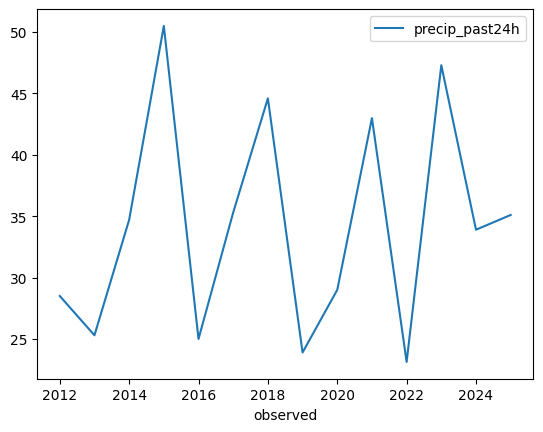